In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [26]:
json_file = json.load(open('results/vanilla.json', 'r'))

json_file = dict(sorted(json_file.items(), key=lambda x: int(x[0])))

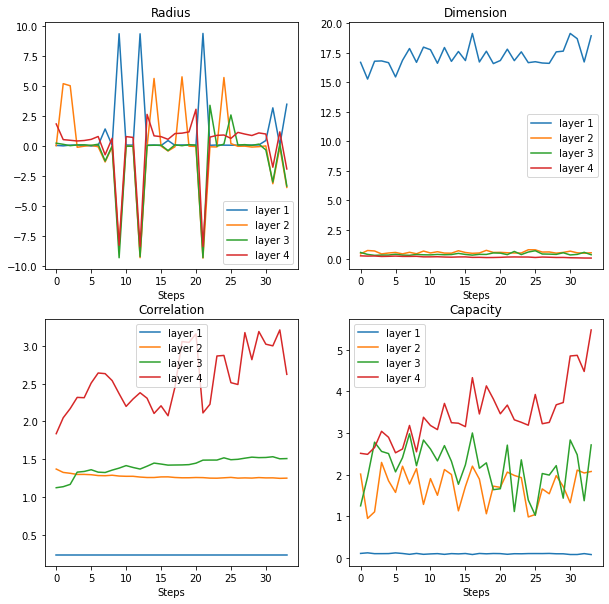

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
properties = ['radius', 'dimension', 'correlation', 'capacity']
titles = ['Radius', 'Dimension', 'Correlation', 'Capacity']

for i, prop in enumerate(properties):
    layers = [[], [], [], []]
    for key, value in json_file.items():
        for j in range(4):
            if prop == 'radius':
                layers[j].append(np.log(value[prop][j]) if j == 0 else np.log(value[prop][j]/value[prop][0]))
            else:
                layers[j].append(value[prop][j] if j == 0 else value[prop][j]/value[prop][0])

    ax[i//2, i%2].plot(layers[0], label='layer 1')
    ax[i//2, i%2].plot(layers[1], label='layer 2')
    ax[i//2, i%2].plot(layers[2], label='layer 3')
    ax[i//2, i%2].plot(layers[3], label='layer 4')
    ax[i//2, i%2].set_title(titles[i])
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel('Steps')

fig.savefig('results/vanilla.jpg')